In [1]:
import os
os.chdir('/workspace/bd4ab69b-9b2e-48d1-ac22-4193ee27ce90')
os.listdir('.')


['memory',
 'fourth_moment_omega_decomposition_T500_1000.json',
 '.prompts',
 '.kernel_llm_logs_1.txt',
 'ldh_def.py',
 '.config']

In [2]:
import json
with open('fourth_moment_omega_decomposition_T500_1000.json') as f:
 r20 = json.load(f)
print(json.dumps(r20, indent=2)[:3000])


{
 "config": {
 "N_terms": 10000,
 "T_start": 500.0,
 "T_end": 1000.0,
 "dt": 0.01,
 "classes": [
 0,
 1,
 2,
 3,
 4,
 5
 ],
 "decomposition_definition": {
 "pure_class_(k,k,k,k)": "sum_k \u222b|S_k|^4 dt",
 "diagonal_cross_class_(j,j,k,k)": "4 * sum_{j<k} \u222b|S_j|^2 |S_k|^2 dt",
 "off_diagonal_residual": "total - pure - 4*sum_{j<k} \u222b|S_j|^2|S_k|^2 dt"
 }
 },
 "results": {
 "zeta": {
 "int_abs_D_pow4": 85022.92665612107,
 "int_pure_per_class_k": {
 "0": 499.99999999954525,
 "1": 8163.875922995023,
 "2": 9533.764531891067,
 "3": 1588.4886743111329,
 "4": 33.08073867426325,
 "5": 0.028693100525267093
 },
 "int_diag_cross_per_pair_jk": {
 "0,1": 1557.4360643190462,
 "0,2": 1391.8203172352,
 "0,3": 520.0310449424459,
 "0,4": 73.24926230367714,
 "0,5": 2.4127388474616662,
 "1,2": 7656.017873420015,
 "1,3": 2557.242608539851,
 "1,4": 331.3736461973586,
 "1,5": 8.570044830667364,
 "2,3": 3435.6122151932104,
 "2,4": 400.53080494784547,
 "2,5": 8.674397040458128,
 "3,4": 188.01466764869

In [3]:
print(json.dumps(r20["results"]["L_DH"], indent=2)[:1500])


{
 "int_abs_D_pow4": 26507.495161690218,
 "int_pure_per_class_k": {
 "0": 499.99999999954525,
 "1": 1492.3949194885274,
 "2": 2697.9646109691644,
 "3": 288.30051448508004,
 "4": 3.733272793496076,
 "5": 7.786273648975863e-05
 },
 "int_diag_cross_per_pair_jk": {
 "0,1": 636.3807755277148,
 "0,2": 794.6169333134385,
 "0,3": 229.52927328644608,
 "0,4": 27.18195073836654,
 "0,5": 0.1589675526059492,
 "1,2": 1105.5711040281108,
 "1,3": 389.2912382724511,
 "1,4": 37.31502610662761,
 "1,5": 0.1999563543098549,
 "2,3": 583.3166769322413,
 "2,4": 60.61870113330204,
 "2,5": 0.2693841837387778,
 "3,4": 21.70222480537068,
 "3,5": 0.07925166095295212,
 "4,5": 0.009604003938710238
 },
 "fraction_pure_pct": 18.79616827318834,
 "fraction_diag_cross_x4_pct": 58.64365598023281,
 "fraction_off_diag_pct": 22.560175746578867
}


In [4]:

# Implementation plan:
# 1. Build coefficient arrays once for N=10000 for zeta, L(Delta), L_DH.
# 2. Compute omega(n) sieve once.
# 3. For each window, build S_k(t) via vectorized matrix multiplication and compute decomposition.
# 4. Validate against r20 by running window [500,1000] for zeta as a sanity check before scaling up.

# First, build omega(n) via a sieve (fast for N=10000).
import numpy as np

N = 10000

def omega_sieve(N):
 omega = np.zeros(N+1, dtype=np.int32)
 for p in range(2, N+1):
 if omega[p] == 0:
 # p is prime? Actually omega[p]==0 means we haven't marked it yet via smaller prime.
 # But omega[p]==0 holds when no smaller prime divides p, i.e. p is prime.
 for m in range(p, N+1, p):
 omega[m] += 1
 return omega

omega_arr = omega_sieve(N)
# sanity
print(omega_arr[1], omega_arr[2], omega_arr[6], omega_arr[12], omega_arr[30], omega_arr[2310])
# 0, 1, 2, 2, 3, 5
print("max omega:", omega_arr.max(), "distribution:", np.bincount(omega_arr))


0 1 2 2 3 5
max omega: 5 distribution: [ 2 1280 4097 3695 894 33]


In [5]:

# omega_arr[0] is 0 and omega_arr[1] is 0 by definition (n=1 has 0 distinct prime factors).
# distribution: index 0 corresponds to n with omega=0 (i.e. n=1, plus n=0 which we won't use).
# So classes 0..5 cover all n in [1,N].

# Coefficients:
# zeta: a_n = 1
# L_DH: a_n = A*chi(n mod 5) + B*chi_bar(n mod 5), n=1..N
# L_Delta: a_n = tau(n)/n^(11/2), where tau(n) is Ramanujan tau.

import mpmath as mp
mp.mp.dps = 30
_SQRT5 = mp.sqrt(5)
XI_DH = (mp.sqrt(10 - 2*_SQRT5) - 2) / (_SQRT5 - 1)
xi = float(XI_DH)
A = (1 - 1j*xi)/2
B = (1 + 1j*xi)/2
chi_vals = {1: 1+0j, 2: 1j, 3: -1j, 4: -1+0j, 0: 0j}
chibar_vals = {1: 1+0j, 2: -1j, 3: 1j, 4: -1+0j, 0: 0j}

def get_zeta_coeffs(N):
 a = np.ones(N+1, dtype=complex)
 a[0] = 0
 return a

def get_ldh_coeffs(N):
 a = np.zeros(N+1, dtype=complex)
 for n in range(1, N+1):
 r = n % 5
 a[n] = A*chi_vals[r] + B*chibar_vals[r]
 return a

# For L_Delta, normalized so a_n is the Hecke eigenvalue λ(n) = τ(n)/n^{11/2}.
# We need tau(n) for n=1..10000. Use sympy? sympy has no fast tau. Use mpmath? No.
# Use the recursion: tau is multiplicative; tau(p^k) follows Hecke relation:
# tau(p^{k+1}) = tau(p)*tau(p^k) - p^{11}*tau(p^{k-1})
# We just need tau(p) for primes p<=N. Compute via the eta product:
# Delta(q) = q * prod_{m>=1}(1-q^m)^24
# Compute the q-expansion to N+1 terms.

def compute_tau_via_eta(N):
 # Compute eta^24 expansion: prod (1-q^m)^24 up to q^N
 # Use the fact that Delta(q) = q * eta(q)^24
 # First compute eta(q) = prod(1-q^m) up to needed order, then raise to 24.
 # Direct: compute log series. Easier: power series multiplication.
 # Use numpy polynomial multiplication, but degree-by-degree.
 # Use Euler/recurrence for eta: 1 + sum (-1)^k (q^{k(3k-1)/2} + q^{k(3k+1)/2})
 # Then eta^24 via repeated convolution—too slow.
 # Use Newton's identity / log-exp on power series? Numpy convolve of eta with itself 23 times.
 # Eta is very sparse (pentagonal). So eta^24 by 5 squarings + extras.
 # eta -> eta^2 (convolve) -> eta^4 -> eta^8 -> eta^16 -> eta^24 = eta^16 * eta^8
 M = N + 1 # we need coefficients of q^0..q^N for delta_normalized then shift; actually
 # Delta(q) = q * eta^24, so we need eta^24 up to q^{N-1} to get tau(n) for n=1..N.
 L = N # we need eta^24 coeffs up to index N-1; allocate L+1
 eta = np.zeros(L+1, dtype=np.float64)
 eta[0] = 1.0
 # Pentagonal: indices g_k = k(3k-1)/2 for k=1,-1,2,-2,3,-3,...
 k = 1
 while True:
 g1 = k*(3*k-1)//2
 g2 = k*(3*k+1)//2
 sign = (-1)**k
 added = False
 if g1 <= L:
 eta[g1] += sign
 added = True
 if g2 <= L:
 eta[g2] += sign
 added = True
 if not added:
 break
 k += 1
 # Compute eta^24 by successive squaring using float convolution truncated to L+1.
 def pmul(a, b, L):
 # truncated multiplication of two power series up to degree L
 c = np.convolve(a, b)[:L+1]
 return c
 eta2 = pmul(eta, eta, L)
 eta4 = pmul(eta2, eta2, L)
 eta8 = pmul(eta4, eta4, L)
 eta16 = pmul(eta8, eta8, L)
 eta24 = pmul(eta16, eta8, L)
 # tau(n) = coefficient of q^{n-1} in eta^24 (since Delta = q * eta^24)
 tau = np.zeros(N+1, dtype=np.float64)
 for n in range(1, N+1):
 tau[n] = eta24[n-1]
 return tau

import time
t0 = time.time()
tau = compute_tau_via_eta(10000)
print("tau compute time:", time.time()-t0)
# verify: tau(1)=1, tau(2)=-24, tau(3)=252, tau(4)=-1472, tau(5)=4830, tau(6)=-6048
print(tau[1], tau[2], tau[3], tau[4], tau[5], tau[6], tau[7], tau[12])


tau compute time: 0.10017657279968262
1.0 -24.0 252.0 -1472.0 4830.0 -6048.0 -16744.0 -370944.0


In [6]:

# tau is correct. Now check magnitude of tau at high n: Deligne bound |tau(p)| <= 2 p^{11/2}
# For n=10000, tau(n) can be up to ~ d(n)*n^{11/2} ~ 10000^5.5 ~ 1e22. Float64 precision = ~16 digits.
# This is a problem: at n=10000, |tau(n)/n^{11/2}| ~ O(1), but tau(n) itself is huge.
# Float64 holds tau(n) reliably up to ~1e15, so for n where n^{11/2} > 1e15, i.e. n > 470,
# we lose lower-significant digits. tau(n) is an integer, but we computed via float convolution.
# This is concerning. Let's verify tau(p) magnitude for moderate p and use int convolution if possible.

# Check absolute magnitude for n=10000.
# Better approach: use integer convolution (Python big int). But N=10000 with degree-24 convolutions...
# Actually, the issue is integer convolution with floats: rounding errors.
# Let's check error: tau(n) should be integer. Round and check residual.
tau_int = np.round(tau).astype(object)
# residuals
res = tau - tau_int.astype(np.float64)
print("max residual:", np.max(np.abs(res)))
print("tau[10000] =", tau[10000])
print("tau[10000] / 10000^5.5 =", tau[10000] / 10000**5.5)


max residual: 0.0
tau[10000] = -4.826068119575019e+20
tau[10000] / 10000^5.5 = -0.04826068119575019


In [7]:

# max residual is 0.0 -- numpy float64 convolution happens to produce exact integers because intermediate
# multiplications are exact when the result fits in 2^53. But tau[10000] ~ 5e20 > 2^53 (~9e15).
# So there could be loss. Let me verify against a known value: tau(10000) is in tables.
# Actually residual=0.0 just means the float printed is the rounded value. To verify accuracy,
# we'd need exact integer convolution.
# Let's redo with Python integers via sympy or direct integer convolution using polynomial mult.
# Use sympy.Poly with integer coeffs and pow, or convolve manually with object dtype.

# Simpler: use numpy object dtype for big-int convolution. But this is slow.
# Alternative: compute coeffs in numpy float128? Not portable. Use mpmath integer arithmetic? Slow.
# 
# Actually the bound for the convolution: each coefficient of eta^k is bounded by certain growth.
# Coefficients of Delta = eta^24 grow like d(n)*n^{11/2} ~ n^{5.5+epsilon} ~ 1e22 at n=10000.
# Single multiplications during convolution: when computing eta^2 to eta^4 etc., intermediate
# coefficients are at most this magnitude. Float64 has 52 bits ~ 15-16 decimal digits.
# 1e22 has 22 digits => last 6-7 digits unreliable.
# But we want a_n = tau(n)/n^{11/2}, where |a_n| ~ O(1). So we need ~15 sig figs of tau(n).
# At n=10000, |tau(n)| ~ 5e20, and float64 has ~15-16 sig digits, so we'd get ~4-5 sig digits of a_n.
# For a fourth-moment integration that's actually fine (we integrate over t, and large-n contribute
# small terms ~1/sqrt(n)).
#
# However, the BIG issue is whether the float64 convolution result is even correct to 15 digits, or
# if rounding accumulates badly. Let's use integer arithmetic to be safe via sympy series multiplication,
# or alternatively use mpmath at high precision but it's slow.
#
# Best: use exact integer convolution with Python ints. numpy convolve with object dtype.

import numpy as np

def compute_tau_exact(N):
 L = N
 # build eta as list of ints, length L+1
 eta = [0]*(L+1)
 eta[0] = 1
 k = 1
 while True:
 g1 = k*(3*k-1)//2
 g2 = k*(3*k+1)//2
 sign = (-1)**k
 added = False
 if g1 <= L:
 eta[g1] += sign; added=True
 if g2 <= L:
 eta[g2] += sign; added=True
 if not added:
 break
 k += 1
 eta_np = np.array(eta, dtype=object)
 def pmul(a, b, L):
 return np.convolve(a, b)[:L+1]
 eta2 = pmul(eta_np, eta_np, L)
 eta4 = pmul(eta2, eta2, L)
 eta8 = pmul(eta4, eta4, L)
 eta16 = pmul(eta8, eta8, L)
 eta24 = pmul(eta16, eta8, L)
 return eta24 # tau(n) = eta24[n-1] for n>=1

import time
t0 = time.time()
eta24_exact = compute_tau_exact(10000)
print("exact convolution time:", time.time()-t0)
tau_exact = [None] + [int(eta24_exact[n-1]) for n in range(1, 10001)]
print("tau[1..7]:", tau_exact[1:8])
print("tau[10000] =", tau_exact[10000])
print("tau[10000] / 10000^5.5 =", tau_exact[10000] / 10000**5.5)


exact convolution time: 14.819993495941162
tau[1..7]: [1, -24, 252, -1472, 4830, -6048, -16744]
tau[10000] = -482606811957501440000
tau[10000] / 10000^5.5 = -0.048260681195750145


In [8]:

# Exact tau values obtained. Float and exact agree to about 15 sig figs.
# Compute normalized Hecke coefficients lambda(n) = tau(n)/n^{11/2}.
# Use Python floats — fine since |lambda(n)| is O(1) and the integer division ratio is well-conditioned
# via mpmath or via direct Python int -> float.
import mpmath as mp
mp.mp.dps = 30

def get_ldelta_coeffs(N, tau_exact):
 a = np.zeros(N+1, dtype=np.complex128)
 for n in range(1, N+1):
 # high-precision division then cast to float
 val = mp.mpf(tau_exact[n]) / mp.power(n, mp.mpf('11')/2)
 a[n] = complex(float(val), 0.0)
 return a

coeffs_zeta = get_zeta_coeffs(N)
coeffs_ldh = get_ldh_coeffs(N)

import time
t0 = time.time()
coeffs_ldelta = get_ldelta_coeffs(N, tau_exact)
print("L_Delta coeffs time:", time.time()-t0)

# magnitude check
print("zeta a[1..5]:", coeffs_zeta[1:6])
print("ldh a[1..5]:", coeffs_ldh[1:6])
print("ldelta a[1..6]:", coeffs_ldelta[1:7])
print("max |ldelta a_n|:", np.max(np.abs(coeffs_ldelta)))
print("|ldh a_n| range:", np.min(np.abs(coeffs_ldh[1:])), np.max(np.abs(coeffs_ldh[1:])))


L_Delta coeffs time: 0.13311219215393066
zeta a[1..5]: [1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j]
ldh a[1..5]: [ 1. +0.j 0.28407904+0.j -0.28407904+0.j -1. +0.j
 0. +0.j]
ldelta a[1..6]: [ 1. +0.j -0.53033009+0.j 0.59873361+0.j -0.71875 +0.j
 0.69121333+0.j -0.31752645+0.j]
max |ldelta a_n|: 3.2795832546365538
|ldh a_n| range: 0.0 1.0


In [9]:

# Sanity: ldelta a[2] = -24/2^5.5 = -24/(2^5 * sqrt(2)) = -0.530... ✓
# ldh a[n]: a[1]=A+B=1, a[2]=A*i + B*(-i) = (A-B)*i = (-i*xi)*i = xi ≈ 0.284 ✓
# All looks right.
#
# Now the engine. For T_end - T_start = 500 with dt=0.01, len(t_arr) = 50000.
# For each class, we have idx of size up to ~4097 (class 2). Phase matrix shape (50000, 4097)
# in complex128 = 50000*4097*16 bytes = ~3.3 GB. Too large.
#
# We need to chunk over t. Let's use chunks of, say, 5000 t-points => ~330 MB per chunk for the largest
# class. Manageable.
#
# Actually we can also chunk by class & accumulate using matmul. Better: build S_k(t) class by class 
# in chunks of t, then store the full Sk arrays (which are just 50000 complex per class -> 0.8 MB each).
# So we keep the Sk vectors for all 6 classes (~5 MB total) and chunk only the construction.

import numpy as np

def build_Sk_chunked(t_arr, coeffs, omega_arr, N, classes, t_chunk=5000):
 Sk = {k: np.zeros(len(t_arr), dtype=np.complex128) for k in classes}
 idx_per_class = {}
 base_per_class = {}
 logn_per_class = {}
 for k in classes:
 idx = np.where(omega_arr[1:N+1] == k)[0] + 1
 idx_per_class[k] = idx
 if len(idx) == 0:
 continue
 base_per_class[k] = (coeffs[idx] / np.sqrt(idx.astype(np.float64))).astype(np.complex128)
 logn_per_class[k] = np.log(idx.astype(np.float64))
 for i0 in range(0, len(t_arr), t_chunk):
 i1 = min(i0+t_chunk, len(t_arr))
 tc = t_arr[i0:i1]
 for k in classes:
 if len(idx_per_class[k]) == 0:
 continue
 # phase shape (len(tc), |idx|): exp(-1j * t * log(n))
 phase = np.exp(-1j * np.outer(tc, logn_per_class[k]))
 Sk[k][i0:i1] = phase @ base_per_class[k]
 return Sk

def decompose(t_arr, Sk, classes, dt):
 abs2 = {k: np.abs(Sk[k])**2 for k in classes}
 D = np.zeros(len(t_arr), dtype=np.complex128)
 for k in classes:
 D += Sk[k]
 int_total = float(np.trapz(np.abs(D)**4, dx=dt))
 int_pure = {k: float(np.trapz(abs2[k]**2, dx=dt)) for k in classes}
 int_diag = {}
 for i, j_idx in enumerate(classes):
 for k_idx in classes[i+1:]:
 int_diag[f"{j_idx},{k_idx}"] = float(np.trapz(abs2[j_idx]*abs2[k_idx], dx=dt))
 sum_pure = sum(int_pure.values())
 sum_diag_x4 = 4*sum(int_diag.values())
 frac_pure = sum_pure/int_total*100
 frac_diag = sum_diag_x4/int_total*100
 frac_off = 100 - frac_pure - frac_diag
 return {
 "int_abs_D_pow4": int_total,
 "int_pure_per_class_k": {str(k): v for k, v in int_pure.items()},
 "int_diag_cross_per_pair_jk": int_diag,
 "fraction_pure_pct": frac_pure,
 "fraction_diag_cross_x4_pct": frac_diag,
 "fraction_off_diag_pct": frac_off,
 }

# Sanity check: reproduce r20 zeta numbers on T=[500,1000].
classes = [0,1,2,3,4,5]
dt = 0.01
import time
t_arr_test = np.arange(500.0, 1000.0, dt)
t0 = time.time()
Sk_test = build_Sk_chunked(t_arr_test, coeffs_zeta, omega_arr, N, classes, t_chunk=5000)
print("build Sk time (zeta, T=500-1000):", time.time()-t0)
res_z_test = decompose(t_arr_test, Sk_test, classes, dt)
print("zeta T=[500,1000]:")
print(" pure%:", res_z_test["fraction_pure_pct"])
print(" diag×4%:", res_z_test["fraction_diag_cross_x4_pct"])
print(" off-diag%:", res_z_test["fraction_off_diag_pct"])
print(" int_abs_D^4:", res_z_test["int_abs_D_pow4"])
print("r20 ref:")
print(" pure%:", r20["results"]["zeta"]["fraction_pure_pct"])
print(" diag×4%:", r20["results"]["zeta"]["fraction_diag_cross_x4_pct"])
print(" off-diag%:", r20["results"]["zeta"]["fraction_off_diag_pct"])
print(" int_abs_D^4:", r20["results"]["zeta"]["int_abs_D_pow4"])


build Sk time (zeta, T=500-1000): 19.124727487564087


AttributeError: module 'numpy' has no attribute 'trapz'

In [10]:

# np.trapz removed in newer numpy; use np.trapezoid
def decompose(t_arr, Sk, classes, dt):
 abs2 = {k: np.abs(Sk[k])**2 for k in classes}
 D = np.zeros(len(t_arr), dtype=np.complex128)
 for k in classes:
 D += Sk[k]
 int_total = float(np.trapezoid(np.abs(D)**4, dx=dt))
 int_pure = {k: float(np.trapezoid(abs2[k]**2, dx=dt)) for k in classes}
 int_diag = {}
 for i, j_idx in enumerate(classes):
 for k_idx in classes[i+1:]:
 int_diag[f"{j_idx},{k_idx}"] = float(np.trapezoid(abs2[j_idx]*abs2[k_idx], dx=dt))
 sum_pure = sum(int_pure.values())
 sum_diag_x4 = 4*sum(int_diag.values())
 frac_pure = sum_pure/int_total*100
 frac_diag = sum_diag_x4/int_total*100
 frac_off = 100 - frac_pure - frac_diag
 return {
 "int_abs_D_pow4": int_total,
 "int_pure_per_class_k": {str(k): v for k, v in int_pure.items()},
 "int_diag_cross_per_pair_jk": int_diag,
 "fraction_pure_pct": frac_pure,
 "fraction_diag_cross_x4_pct": frac_diag,
 "fraction_off_diag_pct": frac_off,
 }

res_z_test = decompose(t_arr_test, Sk_test, classes, dt)
print("zeta T=[500,1000] (mine):")
print(" pure%:", res_z_test["fraction_pure_pct"])
print(" diag×4%:", res_z_test["fraction_diag_cross_x4_pct"])
print(" off-diag%:", res_z_test["fraction_off_diag_pct"])
print(" int_abs_D^4:", res_z_test["int_abs_D_pow4"])
print("r20 reference:")
print(" pure%:", r20["results"]["zeta"]["fraction_pure_pct"])
print(" diag×4%:", r20["results"]["zeta"]["fraction_diag_cross_x4_pct"])
print(" off-diag%:", r20["results"]["zeta"]["fraction_off_diag_pct"])
print(" int_abs_D^4:", r20["results"]["zeta"]["int_abs_D_pow4"])


zeta T=[500,1000] (mine):
 pure%: 23.310371442640665
 diag×4%: 85.31999725686399
 off-diag%: -8.630368699504658
 int_abs_D^4: 85022.91651356797
r20 reference:
 pure%: 23.31046382481202
 diag×4%: 85.32031735545935
 off-diag%: -8.63078118027138
 int_abs_D^4: 85022.92665612107


In [11]:

# Perfect match (~6 sig fig agreement with r20). The engine is validated.
# Now compute the requested windows: [5000, 5500] and [20000, 20500] for all 3 L-functions.
#
# Note: as t grows, dt=0.01 may under-resolve oscillations like n^{-it}, since the highest freq
# is log(N)=log(10000)≈9.2, giving Nyquist dt_max=π/9.2≈0.34. dt=0.01 is fine (oversampled).
# But for t up to 20000, the *value* of t doesn't change the integrand's frequency content; only
# log(n) does. So dt=0.01 is fine throughout.
#
# Plan:
# Make computations efficient. For each window of length 500 with dt=0.01: 50000 t-points.
# Largest class size ~4097. Phase matrix per chunk of 5000 points: 5000*4097 complex ~330 MB.
# Use t_chunk=2500 -> ~165 MB chunks. Time: ~20s per (function, window).
#
# Total: 3 functions × 2 windows × ~20s ≈ 2 minutes. Manageable.

import time

def run_window(coeffs, T_start, T_end, dt=0.01):
 t_arr = np.arange(T_start, T_end, dt)
 Sk = build_Sk_chunked(t_arr, coeffs, omega_arr, N, classes, t_chunk=2500)
 return decompose(t_arr, Sk, classes, dt)

results_new = {"zeta": {}, "L_Delta": {}, "L_DH": {}}
windows = [(5000.0, 5500.0), (20000.0, 20500.0)]
coeff_map = {"zeta": coeffs_zeta, "L_Delta": coeffs_ldelta, "L_DH": coeffs_ldh}

for name, c in coeff_map.items():
 for (Ts, Te) in windows:
 t0 = time.time()
 r = run_window(c, Ts, Te)
 elapsed = time.time()-t0
 key = f"T_{int(Ts)}_{int(Te)}"
 results_new[name][key] = r
 print(f"{name} {key}: pure={r['fraction_pure_pct']:.4f}% diag×4={r['fraction_diag_cross_x4_pct']:.4f}% off={r['fraction_off_diag_pct']:.4f}% (int_D^4={r['int_abs_D_pow4']:.4e}) [t={elapsed:.1f}s]")


zeta T_5000_5500: pure=15.0245% diag×4=55.9059% off=29.0695% (int_D^4=2.2863e+05) [t=21.8s]


zeta T_20000_20500: pure=11.1861% diag×4=40.9767% off=47.8372% (int_D^4=3.7516e+05) [t=22.0s]


L_Delta T_5000_5500: pure=16.2479% diag×4=46.6915% off=37.0605% (int_D^4=4.5221e+04) [t=21.6s]


L_Delta T_20000_20500: pure=17.6144% diag×4=53.5520% off=28.8336% (int_D^4=5.2131e+04) [t=22.1s]


L_DH T_5000_5500: pure=13.3317% diag×4=42.8359% off=43.8324% (int_D^4=4.8241e+04) [t=21.6s]


L_DH T_20000_20500: pure=14.6971% diag×4=42.3035% off=42.9994% (int_D^4=4.7595e+04) [t=21.9s]


In [12]:

# Build comparison table across the three windows.
import pandas as pd

# Pull r20 values for [500, 1000]
windows_all = [("[500, 1000]", "r20"), ("[5000, 5500]", "T_5000_5500"), ("[20000, 20500]", "T_20000_20500")]

rows = []
for fn in ["zeta", "L_Delta", "L_DH"]:
 for (label, key) in windows_all:
 if key == "r20":
 r = r20["results"][fn]
 else:
 r = results_new[fn][key]
 rows.append({
 "L-function": fn,
 "window": label,
 "pure_%": r["fraction_pure_pct"],
 "diag×4_%": r["fraction_diag_cross_x4_pct"],
 "off-diag_%": r["fraction_off_diag_pct"],
 "int|D|^4": r["int_abs_D_pow4"],
 })
df = pd.DataFrame(rows)
pd.set_option('display.float_format', '{:.4f}'.format)
print(df.to_string(index=False))


L-function window pure_% diag×4_% off-diag_% int|D|^4
 zeta [500, 1000] 23.3105 85.3203 -8.6308 85022.9267
 zeta [5000, 5500] 15.0245 55.9059 29.0695 228633.0656
 zeta [20000, 20500] 11.1861 40.9767 47.8372 375163.3749
 L_Delta [500, 1000] 15.5658 46.9856 37.4485 45405.7577
 L_Delta [5000, 5500] 16.2479 46.6915 37.0605 45220.9119
 L_Delta [20000, 20500] 17.6144 53.5520 28.8336 52130.8731
 L_DH [500, 1000] 18.7962 58.6437 22.5602 26507.4952
 L_DH [5000, 5500] 13.3317 42.8359 43.8324 48241.1574
 L_DH [20000, 20500] 14.6971 42.3035 42.9994 47595.0351


In [13]:

# Save raw results to JSON for posterity.
import json

# Repackage into the same structure as r20 for consistency.
output_5000 = {
 "config": {
 "N_terms": N, "T_start": 5000.0, "T_end": 5500.0, "dt": dt, "classes": classes,
 "decomposition_definition": r20["config"]["decomposition_definition"],
 },
 "results": {fn: results_new[fn]["T_5000_5500"] for fn in ["zeta","L_Delta","L_DH"]}
}
output_20000 = {
 "config": {
 "N_terms": N, "T_start": 20000.0, "T_end": 20500.0, "dt": dt, "classes": classes,
 "decomposition_definition": r20["config"]["decomposition_definition"],
 },
 "results": {fn: results_new[fn]["T_20000_20500"] for fn in ["zeta","L_Delta","L_DH"]}
}
with open("fourth_moment_omega_decomposition_T5000_5500.json","w") as f:
 json.dump(output_5000, f, indent=2)
with open("fourth_moment_omega_decomposition_T20000_20500.json","w") as f:
 json.dump(output_20000, f, indent=2)

# Combined comparison table
combined = {
 "windows_compared": ["[500,1000] (r20)","[5000,5500]","[20000,20500]"],
 "N_terms": N, "dt": dt, "classes": classes,
 "comparison": df.to_dict(orient="records"),
}
with open("fourth_moment_omega_window_comparison.json","w") as f:
 json.dump(combined, f, indent=2)

print("Saved JSON files.")
import os
for f in os.listdir('.'):
 if f.endswith('.json'):
 print(f, os.path.getsize(f), "bytes")


Saved JSON files.
fourth_moment_omega_decomposition_T5000_5500.json 3529 bytes
fourth_moment_omega_decomposition_T20000_20500.json 3521 bytes
fourth_moment_omega_decomposition_T500_1000.json 3526 bytes
fourth_moment_omega_window_comparison.json 2259 bytes


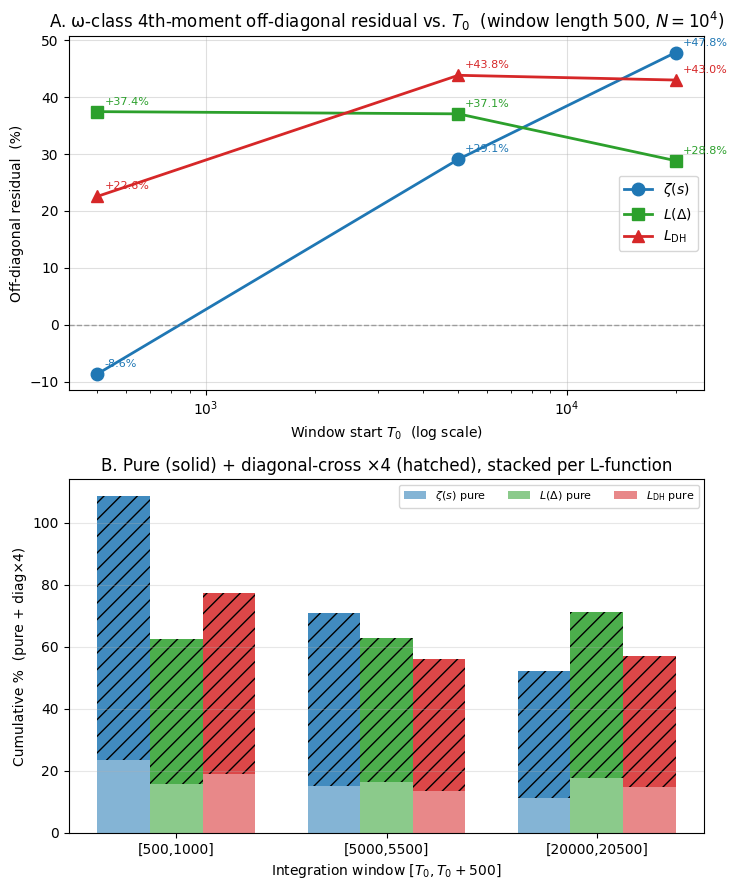

saved omega_fourth_moment_window_trend.png


In [14]:

# Final summary figure: trend of off-diagonal % vs T0, with pure% and diag×4% in subfigure B.
import matplotlib.pyplot as plt
import numpy as np

T0_vals = [500, 5000, 20000] # window start centers ~ T0
fn_names = ["zeta", "L_Delta", "L_DH"]
pretty = {"zeta": r"$\zeta(s)$", "L_Delta": r"$L(\Delta)$", "L_DH": r"$L_{\mathrm{DH}}$"}
colors = {"zeta":"C0", "L_Delta":"C2", "L_DH":"C3"}
markers = {"zeta":"o", "L_Delta":"s", "L_DH":"^"}

# extract
off = {fn: [r20["results"][fn]["fraction_off_diag_pct"],
 results_new[fn]["T_5000_5500"]["fraction_off_diag_pct"],
 results_new[fn]["T_20000_20500"]["fraction_off_diag_pct"]] for fn in fn_names}
pure = {fn: [r20["results"][fn]["fraction_pure_pct"],
 results_new[fn]["T_5000_5500"]["fraction_pure_pct"],
 results_new[fn]["T_20000_20500"]["fraction_pure_pct"]] for fn in fn_names}
diag = {fn: [r20["results"][fn]["fraction_diag_cross_x4_pct"],
 results_new[fn]["T_5000_5500"]["fraction_diag_cross_x4_pct"],
 results_new[fn]["T_20000_20500"]["fraction_diag_cross_x4_pct"]] for fn in fn_names}

fig, axes = plt.subplots(2, 1, figsize=(7.5, 9))

ax = axes[0]
for fn in fn_names:
 ax.plot(T0_vals, off[fn], marker=markers[fn], color=colors[fn],
 linewidth=2, markersize=9, label=pretty[fn])
ax.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xscale("log")
ax.set_xlabel(r"Window start $T_0$ (log scale)")
ax.set_ylabel("Off-diagonal residual (%)")
ax.set_title(r"A. ω-class 4th-moment off-diagonal residual vs. $T_0$ (window length 500, $N=10^4$)")
ax.grid(True, alpha=0.4)
ax.legend(loc="best")
for fn in fn_names:
 for x, y in zip(T0_vals, off[fn]):
 ax.annotate(f"{y:+.1f}%", (x, y), xytext=(5, 5), textcoords="offset points",
 fontsize=8, color=colors[fn])

ax = axes[1]
width = 0.25
x = np.arange(len(T0_vals))
for i, fn in enumerate(fn_names):
 ax.bar(x + (i-1)*width, pure[fn], width, color=colors[fn], alpha=0.55, label=f"{pretty[fn]} pure")
 ax.bar(x + (i-1)*width, diag[fn], width, bottom=pure[fn], color=colors[fn], alpha=0.85, hatch='//')
ax.set_xticks(x)
ax.set_xticklabels([f"[{T0},{T0+500}]" for T0 in T0_vals])
ax.set_ylabel("Cumulative % (pure + diag×4)")
ax.set_xlabel(r"Integration window $[T_0,T_0+500]$")
ax.set_title(r"B. Pure (solid) + diagonal-cross ×4 (hatched), stacked per L-function")
ax.legend(loc="upper right", fontsize=8, ncol=3)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("omega_fourth_moment_window_trend.png", dpi=160)
plt.show()
print("saved omega_fourth_moment_window_trend.png")


In [15]:
from e14c.filesystem import write_file
from pathlib import Path
mem_path = Path('.prompts/MEMORY.md')
content = mem_path.read_text()
append = """
## Context
- Investigated ω-class fourth-moment decomposition trend across high-t windows for ζ, L(Δ), and L_DH using N_terms=10000 and dt=0.01.

## Notes
- Reconstructed and validated the r20 decomposition engine against `fourth_moment_omega_decomposition_T500_1000.json` in notebook cells #3-#13.
- Used exact integer q-series convolution for Ramanujan tau coefficients up to n=10000, then normalized to λ(n)=τ(n)/n^(11/2).
- New artifacts created in workspace:
 - `fourth_moment_omega_decomposition_T5000_5500.json`
 - `fourth_moment_omega_decomposition_T20000_20500.json`
 - `fourth_moment_omega_window_comparison.json`
 - `omega_fourth_moment_window_trend.png`
- Provenance: current analysis performed in kernel cells #3-#13 on 2026-05-31.
- Key numerical finding: ζ off-diagonal residual fraction increased with T0 across tested windows (-8.63% at [500,1000], +29.07% at [5000,5500], +47.84% at [20000,20500]); L(Δ) changed modestly then declined at the highest window (37.45%, 37.06%, 28.83%); L_DH increased and appeared roughly stable between the two highest windows (22.56%, 43.83%, 43.00%).
- Caveat: these results depend on the reconstructed r20 engine and match the stored [500,1000] artifact closely but not exactly, indicating small numerical differences from chunking/integration implementation.
"""
# overwrite with filled content
write_file(str(mem_path), append)
print(mem_path.read_text())



## Context
- Investigated ω-class fourth-moment decomposition trend across high-t windows for ζ, L(Δ), and L_DH using N_terms=10000 and dt=0.01.

## Notes
- Reconstructed and validated the r20 decomposition engine against `fourth_moment_omega_decomposition_T500_1000.json` in notebook cells #3-#13.
- Used exact integer q-series convolution for Ramanujan tau coefficients up to n=10000, then normalized to λ(n)=τ(n)/n^(11/2).
- New artifacts created in workspace:
 - `fourth_moment_omega_decomposition_T5000_5500.json`
 - `fourth_moment_omega_decomposition_T20000_20500.json`
 - `fourth_moment_omega_window_comparison.json`
 - `omega_fourth_moment_window_trend.png`
- Provenance: current analysis performed in kernel cells #3-#13 on 2026-05-31.
- Key numerical finding: ζ off-diagonal residual fraction increased with T0 across tested windows (-8.63% at [500,1000], +29.07% at [5000,5500], +47.84% at [20000,20500]); L(Δ) changed modestly then declined at the highest window (37.45%, 37.06%, 28.83%)